In [306]:
from qiskit import *
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from math import pi
%matplotlib inline

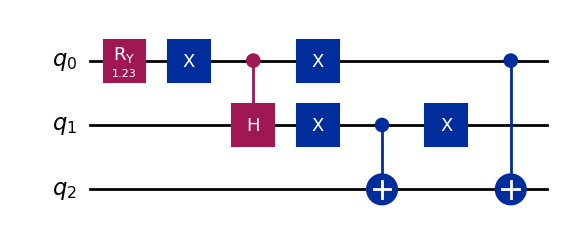

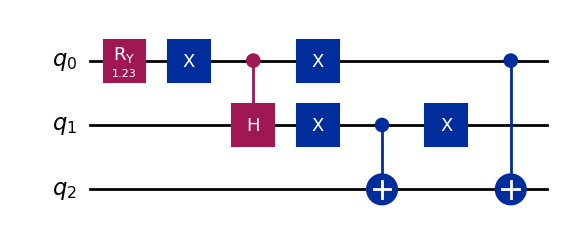

In [307]:
circuit = QuantumCircuit(3)

#Challenge 1 - GHZ basis vector
#circuit.h(0)
#circuit.cx(0,[1,2])

#Challenge 2 - equal parts |001>, |010>, |100>
circuit.ry(1.231,0)
circuit.x(0)    #1/3 zero gate check
circuit.ch(0,1) #2/3
circuit.x(0)    #3/3
circuit.x(1)    #1/3 zero gate check
circuit.cx(1,2) #2/3
circuit.x(1)    #3/3
circuit.cx(0,2)

circuit.draw(output='mpl')

In [308]:
# UPDATE: Code updated after recording to resolve breaking changes from Qiskit 1.0
circuit.remove_final_measurements()  # no measurements allowed
from qiskit.quantum_info import Statevector
statevector = Statevector(circuit)
array_to_latex(statevector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

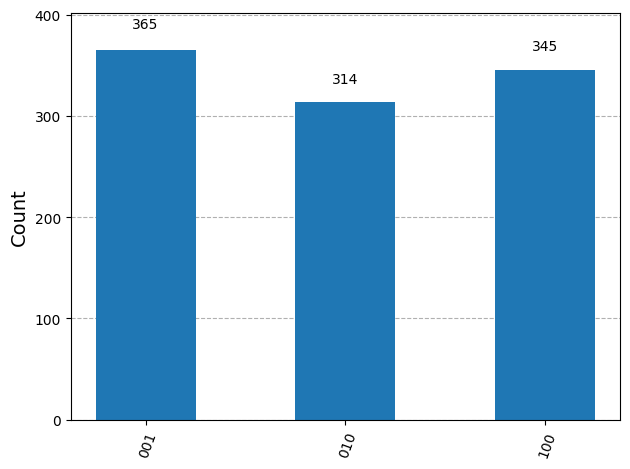

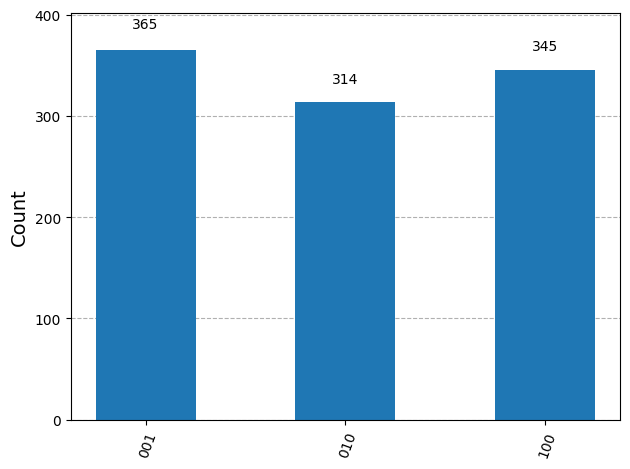

In [309]:
circuit.measure_all()

# UPDATE: Code updated after recording to resolve breaking changes from Qiskit 1.0
from qiskit.providers.basic_provider import BasicProvider
simulator = BasicProvider().get_backend('basic_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit).result()
plot_histogram(result.get_counts())

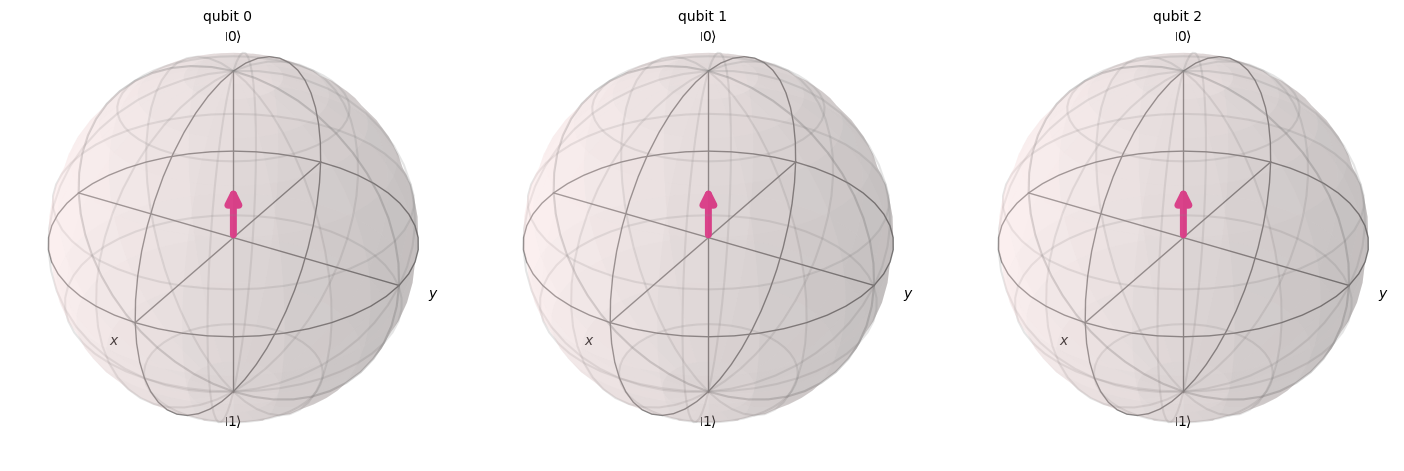

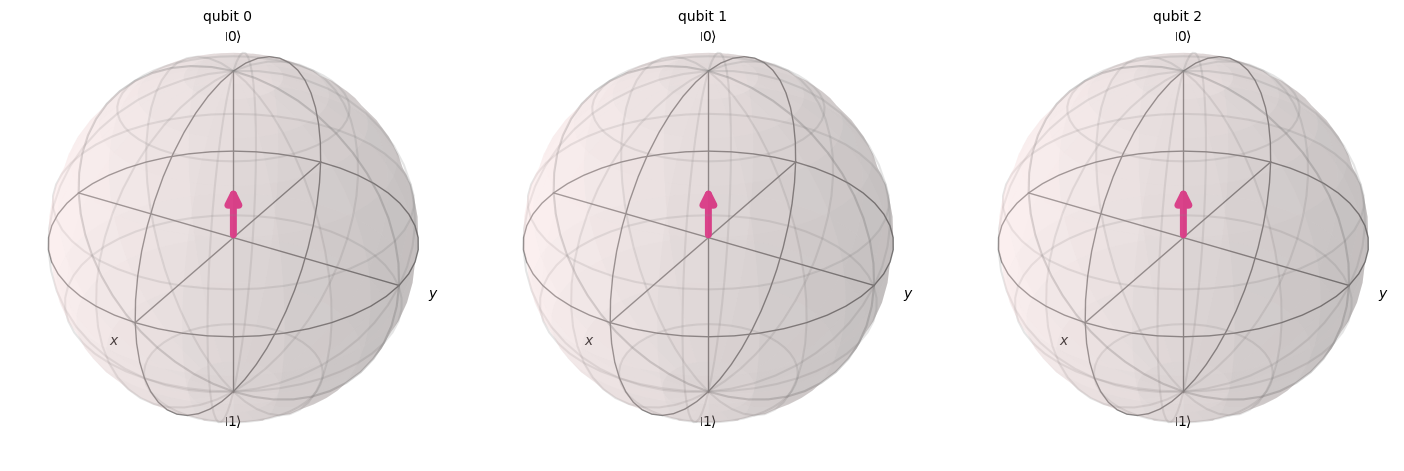

In [310]:
circuit.remove_final_measurements()
from qiskit.quantum_info import Statevector
statevector = Statevector(circuit)
plot_bloch_multivector(circuit)